# **Variables Aleatorias**


---



Antes de clasificar las distribuciones, debemos entender qué es una variable aleatoria.

A pesar de su nombre, matemáticamente no es una variable ni es puramente aleatoria. Es, en realidad, una función que toma los elementos de un espacio muestral (los resultados de un experimento) y les asigna un número real:

$$X: \Omega \to \mathbb{R}$$

Su propósito es "traducir" eventos del mundo real a números con los que podamos operar matemáticamente.

Se dividen en dos grandes familias: discretas y continuas.



---


## **Variables Aleatorias Discretas**


Una variable discreta es aquella cuyo conjunto de valores posibles es finito o infinito numerable (como contar $x \in \{0, 1, 2, \dots\}$).

### **Uniforme Discreta**

Una variable aleatoria discreta es aquella cuyo conjunto de valores posibles es finito o infinito numerable ($x \in \{x_1, x_2, \dots\}$).

Su comportamiento se describe mediante una Función de Masa de Probabilidad (FMP) $p_X(x) = P(X = x)$, la cual cumple que $p_X(x) \ge 0$ y $\sum_x p_X(x) = 1$.

Modela un experimento donde un número finito $n$ de resultados posibles tienen exactamente la misma probabilidad de ocurrir.

**Función de probabilidad:**

$$P(X = x) = \frac{1}{n}, \quad \text{para } x \in \{x_1, x_2, \dots, x_n\}$$

*Es una distribución simétrica respecto a su media cuando los valores están igualmente espaciados.*

**Esperanza:**$$\mathbb{E}[X] = \frac{a + b}{2} \quad \text{(para enteros consecutivos en } [a, b]\text{)}$$

**Varianza:**$$\text{Var}(X) = \frac{(b - a + 1)^2 - 1}{12}$$

**Ejercicio:** Se lanza un dado justo de 6 caras. Calcula la probabilidad de obtener un número mayor o igual a 5, así como su esperanza y varianza.

**Solución:**$$P(X \ge 5) = P(X = 5) + P(X = 6) = \frac{1}{6} + \frac{1}{6} = \frac{2}{6} = \frac{1}{3}$$

$$\mathbb{E}[X] = \frac{1 + 6}{2} = 3.5$$


$$\text{Var}(X) = \frac{(6 - 1 + 1)^2 - 1}{12} = \frac{35}{12} \approx 2.9167$$

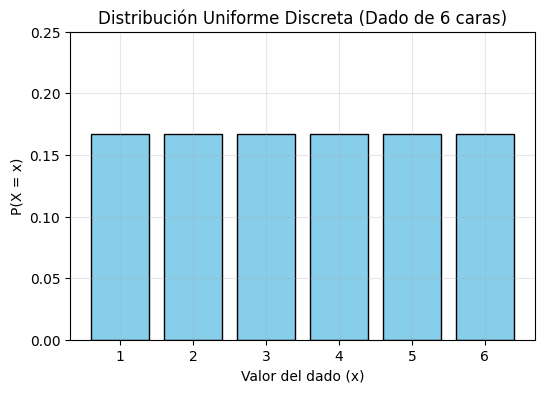

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Lanzamiento de un dado justo de 6 caras
caras = np.arange(1, 7)
prob = np.full(6, 1/6)

plt.figure(figsize=(6, 4))
plt.bar(caras, prob, color='skyblue', edgecolor='black')
plt.title('Distribución Uniforme Discreta (Dado de 6 caras)')
plt.xlabel('Valor del dado (x)')
plt.ylabel('P(X = x)')
plt.ylim(0, 0.25)
plt.grid(True, alpha=0.3)
plt.show()

Cada cara tiene una probabilidad de ocurrencia de aproximadamente 0.1667 o 16.67%, por lo que ninguna presenta ventaja sobre las demás. Esta representación visual permite comprender de manera intuitiva el comportamiento probabilístico de un experimento aleatorio con resultados equiprobables.

###**Distribución Bernoulli**

Lleva el nombre de Jacobo (James) Bernoulli, matemático suizo que a finales del siglo XVII formalizó el estudio de experimentos binarios.

Modela un experimento de un solo ensayo con únicamente dos resultados posibles:

"Éxito" ($X = 1$) con probabilidad $p$, o "Fracaso" ($X = 0$) con probabilidad $1 - p$.

Función de probabilidad:$$P(X = x) = p^x (1-p)^{1-x}, \quad \text{para } x \in \{0, 1\}$$

*Es la celda básica de construcción para las distribuciones Binomial, Geométrica y Binomial Negativa.*

**Esperanza:**$$\mathbb{E}[X] = p$$

**Varianza:**$$\text{Var}(X) = p(1-p)$$

**Ejercicio:** Un estudiante responde una pregunta de opción múltiple con 4 opciones donde solo 1 es correcta. Si responde al azar, determina la probabilidad de acertar, la esperanza y la varianza.

**Solución:** $$p = \frac{1}{4} = 0.25$$

$$P(X = 1) = 0.25$$

$$\mathbb{E}[X] = p = 0.25$$

$$\text{Var}(X) = 0.25(1 - 0.25) = 0.1875$$

Pregunta de opción múltiple
Probabilidad de acertar: P(X=1) = 0.25
Esperanza E[X] = 0.25
Varianza Var(X) = 0.1875


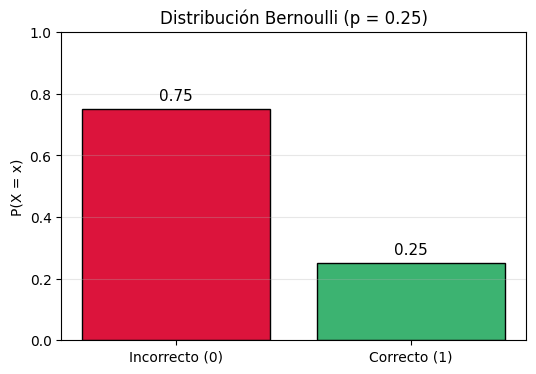

In [52]:
# Probabilidad de acertar una pregunta de 4 opciones
p = 1 / 4

# Distribución de Bernoulli
x = [0, 1]                  # 0 = Incorrecto, 1 = Correcto
probs = [1 - p, p]

# Esperanza y varianza
esperanza = p
varianza = p * (1 - p)

# Mostrar resultados
print("Pregunta de opción múltiple")
print(f"Probabilidad de acertar: P(X=1) = {p:.2f}")
print(f"Esperanza E[X] = {esperanza:.2f}")
print(f"Varianza Var(X) = {varianza:.4f}")

# Gráfica
plt.figure(figsize=(6,4))
plt.bar(
    ['Incorrecto (0)', 'Correcto (1)'],
    probs,
    color=['crimson', 'mediumseagreen'],
    edgecolor='black'
)

plt.title('Distribución Bernoulli (p = 0.25)')
plt.ylabel('P(X = x)')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Mostrar el valor de cada barra
for i, prob in enumerate(probs):
    plt.text(i, prob + 0.03, f"{prob:.2f}", ha='center', fontsize=11)

plt.show()

Debido a que existe una sola respuesta correcta entre cuatro posibles, la probabilidad de éxito es del 25%, mientras que la probabilidad de fracaso es del 75%. Este ejemplo ilustra cómo la distribución de Bernoulli modela experimentos con únicamente dos resultados posibles y permite calcular medidas importantes como la esperanza y la varianza para describir el comportamiento probabilístico del experimento.

### **Distribución Binomial:**

Modela el número de éxitos $k$ al realizar $n$ ensayos independientes de Bernoulli, cada uno con una probabilidad constante de éxito $p$.

**Función de probabilidad:**$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad \text{para } k \in \{0, 1, 2, \dots, n\}$$

**Propiedades:**

Si $X_1 \sim \text{Binomial}(n_1, p)$ y $X_2 \sim \text{Binomial}(n_2, p)$ son independientes, entonces $X_1 + X_2 \sim \text{Binomial}(n_1 + n_2, p)$.Es simétrica cuando $p = 0.5$.

**Esperanza:**$$\mathbb{E}[X] = np$$

**Varianza:**$$\text{Var}(X) = np(1-p)$$

**Ejercicio:** Un examen consta de 10 preguntas de verdadero/falso.

Si un alumno responde todo al azar ($p = 0.5$), ¿cuál es la probabilidad de aprobar obteniendo al menos 6 aciertos?

**Solución:**$$P(X \ge 6) = \sum_{k=6}^{10} \binom{10}{k} (0.5)^k (0.5)^{10-k} \approx 0.37695$$

Examen Verdadero/Falso
Probabilidad de aprobar (6 o más aciertos): 0.37695


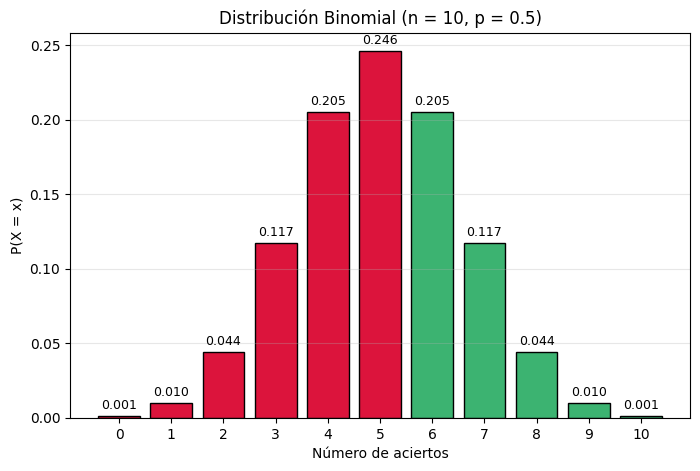

In [53]:
from scipy.stats import binom

# Parámetros del problema
n = 10      # Número de preguntas
p = 0.5     # Probabilidad de acertar cada pregunta

# Valores posibles de aciertos
x = list(range(n + 1))

# Función de masa de probabilidad
probs = binom.pmf(x, n, p)

# Probabilidad de aprobar (6 o más aciertos)
prob_aprobar = binom.sf(5, n, p)   # P(X >= 6)

# Mostrar resultado
print("Examen Verdadero/Falso")
print(f"Probabilidad de aprobar (6 o más aciertos): {prob_aprobar:.5f}")

# Colores: rojo para reprobar, verde para aprobar
colores = ["crimson" if k < 6 else "mediumseagreen" for k in x]

# Gráfica
plt.figure(figsize=(8,5))
plt.bar(x, probs, color=colores, edgecolor='black')

plt.title("Distribución Binomial (n = 10, p = 0.5)")
plt.xlabel("Número de aciertos")
plt.ylabel("P(X = x)")
plt.xticks(x)
plt.grid(axis='y', alpha=0.3)

# Mostrar probabilidades sobre cada barra
for i, prob in enumerate(probs):
    plt.text(i, prob + 0.005, f"{prob:.3f}", ha='center', fontsize=9)

plt.show()

La mayor probabilidad corresponde a obtener alrededor de 5 aciertos, mientras que obtener un número muy bajo o muy alto de respuestas correctas es menos probable. Asimismo, el cálculo de $P(X≥6)$ permite estimar la probabilidad de aprobar el examen respondiendo al azar, mostrando cómo la distribución binomial es una herramienta adecuada para analizar experimentos con un número fijo de ensayos independientes y una probabilidad constante de éxito.

### **Distribución Poisson**

Presentada en 1837 por Siméon Denis Poisson en un estudio sobre la probabilidad en juicios criminales y civiles.

Modela la cantidad de eventos independientes que ocurren en un intervalo continuo de tiempo o espacio a una tasa promedio constante $\lambda$.

**Función de probabilidad:**$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad \text{para } k \in \{0, 1, 2, \dots\}$$

**Propiedades:**
Aproxima a una Binomial cuando $n \to \infty$ y $p \to 0$ tal que $np = \lambda$.La suma de dos variables independientes $X_1 \sim \text{Poisson}(\lambda_1)$ y $X_2 \sim \text{Poisson}(\lambda_2)$ es $X_1 + X_2 \sim \text{Poisson}(\lambda_1 + \lambda_2)$.

**Esperanza:**$$\mathbb{E}[X] = \lambda$$
**Varianza:**$$\text{Var}(X) = \lambda$$

**Ejercicio:** Un servidor web recibe un promedio de 3 peticiones por minuto ($\lambda = 3$). ¿Cuál es la probabilidad de recibir exactamente 5 peticiones en un minuto determinado?

**Solución:**$$P(X = 5) = \frac{3^5 e^{-3}}{5!} = \frac{243 \cdot 0.049787}{120} \approx 0.1008$$

Servidor web
Probabilidad de recibir exactamente 5 peticiones: 0.1008


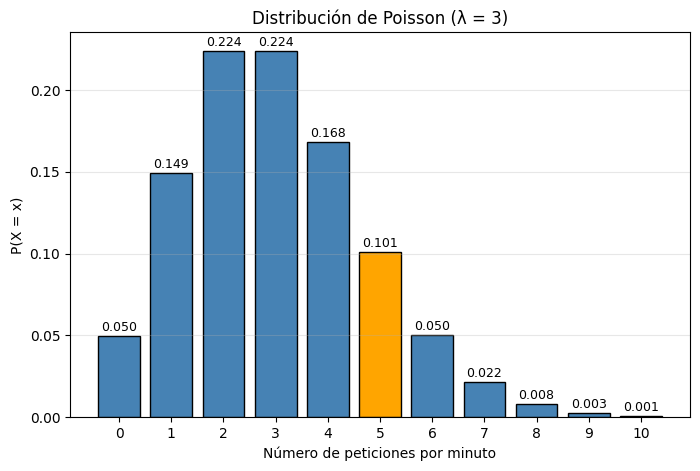

In [54]:
from scipy.stats import poisson
# Parámetro de la distribución
lam = 3  # Promedio de peticiones por minuto

# Valores posibles de peticiones (0 a 10)
x = list(range(11))

# Función de masa de probabilidad
probs = poisson.pmf(x, lam)

# Probabilidad de recibir exactamente 5 peticiones
prob_5 = poisson.pmf(5, lam)

# Mostrar resultado
print("Servidor web")
print(f"Probabilidad de recibir exactamente 5 peticiones: {prob_5:.4f}")

# Colores: resaltar el valor x = 5
colores = ["steelblue" if k != 5 else "orange" for k in x]

# Gráfica
plt.figure(figsize=(8,5))
plt.bar(x, probs, color=colores, edgecolor='black')

plt.title("Distribución de Poisson (λ = 3)")
plt.xlabel("Número de peticiones por minuto")
plt.ylabel("P(X = x)")
plt.xticks(x)
plt.grid(axis='y', alpha=0.3)

# Mostrar probabilidades sobre cada barra
for i, prob in enumerate(probs):
    plt.text(i, prob + 0.003, f"{prob:.3f}", ha='center', fontsize=9)

plt.show()

La mayor probabilidad se concentra en valores cercanos al promedio de tres peticiones por minuto, mientras que recibir una cantidad considerablemente mayor o menor de solicitudes es menos frecuente. Asimismo, el cálculo de $P(X=5)$ permite conocer la probabilidad de que el servidor reciba exactamente cinco peticiones en un minuto, ilustrando cómo la distribución de Poisson es adecuada para modelar la ocurrencia de eventos discretos que suceden de forma independiente y con una tasa promedio constante.

###**Distribución Geométrica**

La distribución Geométrica cuenta el número de ensayos necesarios hasta obtener el primer éxito.

**Función de probabilidad:**$$P(X = k) = (1-p)^{k-1} p, \quad \text{para } k \in \{1, 2, 3, \dots\}$$

**Propiedades:**
Es la única distribución discreta que posee la propiedad de falta de memoria:
$$P(X > m + n \mid X > m) = P(X > n)$$
**Esperanza:** $$\mathbb{E}[X] = \frac{1}{p}$$
**Varianza:**$$\text{Var}(X) = \frac{1-p}{p^2}$$

**Ejercicio:** Un arquero tiene una probabilidad $p = 0.2$ de acertar al blanco en cada tiro. ¿Cuál es el número esperado de lanzamientos para dar en el blanco por primera vez y la probabilidad de necesitar exactamente 3 intentos?

**Solución:**
$$\mathbb{E}[X] = \frac{1}{0.2} = 5 \text{ intentos}$$

$$P(X = 3) = (1 - 0.2)^{3-1} (0.2) = (0.8)^2 (0.2) = 0.128$$

Arquero
Número esperado de intentos: 5
Probabilidad de acertar en el tercer intento: 0.128


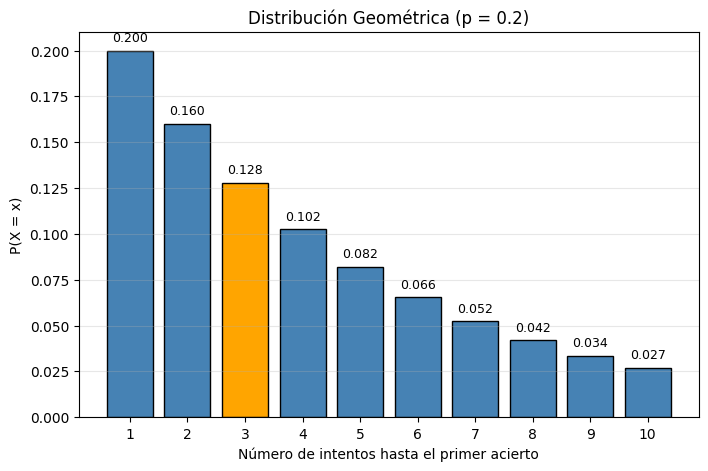

In [55]:
from scipy.stats import geom

# Parámetro de la distribución
p = 0.2  # Probabilidad de acertar en cada intento

# Valores posibles de intentos (1 a 10)
x = list(range(1, 11))

# Función de masa de probabilidad
probs = geom.pmf(x, p)

# Esperanza matemática
esperanza = 1 / p

# Probabilidad de acertar exactamente en el tercer intento
prob_3 = geom.pmf(3, p)

# Mostrar resultados
print("Arquero")
print(f"Número esperado de intentos: {esperanza:.0f}")
print(f"Probabilidad de acertar en el tercer intento: {prob_3:.3f}")

# Colores: resaltar el tercer intento
colores = ["steelblue" if k != 3 else "orange" for k in x]

# Gráfica
plt.figure(figsize=(8,5))
plt.bar(x, probs, color=colores, edgecolor='black')

plt.title("Distribución Geométrica (p = 0.2)")
plt.xlabel("Número de intentos hasta el primer acierto")
plt.ylabel("P(X = x)")
plt.xticks(x)
plt.grid(axis='y', alpha=0.3)

# Mostrar probabilidades sobre cada barra
for i, prob in enumerate(probs):
    plt.text(x[i], prob + 0.005, f"{prob:.3f}", ha='center', fontsize=9)

plt.show()

El modelo indica que el primer acierto es más probable en los primeros intentos y que dicha probabilidad disminuye conforme aumenta el número de disparos requeridos. Además, la esperanza matemática muestra que, en promedio, el arquero necesitará cinco intentos para acertar por primera vez, mientras que el cálculo de $P(X=3)$ permite conocer la probabilidad específica de lograr el primer acierto exactamente en el tercer intento. Este ejemplo ilustra cómo la distribución geométrica describe el comportamiento de experimentos repetitivos hasta la ocurrencia del primer éxito.

###**Distribución Binomial Negativa:**

A diferencia de la Binomial (que cuenta éxitos en n intentos fijos), estas modelan tiempos de espera. La Binomial Negativa es su generalización: cuenta los ensayos hasta obtener r éxitos


**Función de probabilidad:**$$P(X = k) = \binom{k-1}{r-1} p^r (1-p)^{k-r}, \quad \text{para } k \in \{r, r+1, r+2, \dots\}$$

**Propiedades:**

Cuando $r = 1$, la distribución Binomial Negativa se reduce exactamente a la distribución Geométrica.

**Esperanza:**$$\mathbb{E}[X] = \frac{r}{p}$$

**Varianza:**$$\text{Var}(X) = \frac{r(1-p)}{p^2}$$

**Ejercicio:** Se lanza una moneda equilibrada ($p = 0.5$). ¿Cuál es la probabilidad de necesitar exactamente 5 lanzamientos para obtener el segundo Sol ($r = 2$)?

**Solución:**$$P(X = 5) = \binom{5-1}{2-1} (0.5)^2 (1 - 0.5)^{5-2} = \binom{4}{1} (0.5)^2 (0.5)^3 = 4 \cdot (0.5)^5 = 0.125$$

Lanzamiento de moneda
Probabilidad de obtener el segundo Sol en el quinto lanzamiento: 0.125


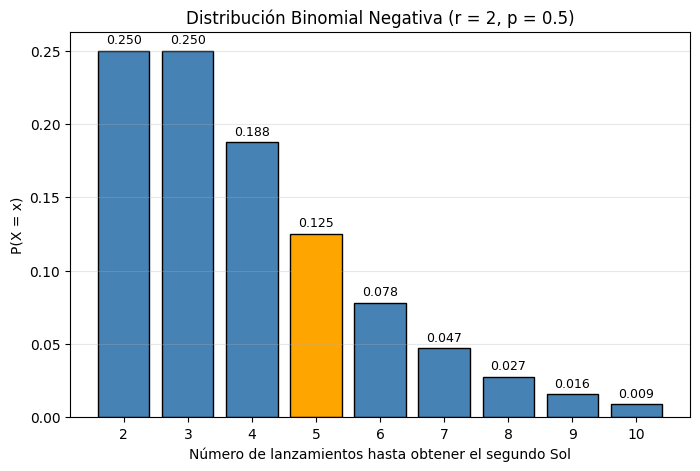

In [56]:
from scipy.stats import nbinom

# Parámetros de la distribución
r = 2      # Número de éxitos deseados (2 Soles)
p = 0.5    # Probabilidad de obtener Sol

# Valores posibles de lanzamientos (desde r hasta 10)
x = list(range(r, 11))

# Función de masa de probabilidad
probs = nbinom.pmf([k - r for k in x], r, p)

# Probabilidad de obtener el segundo Sol exactamente en el quinto lanzamiento
prob_5 = nbinom.pmf(5 - r, r, p)

# Mostrar resultado
print("Lanzamiento de moneda")
print(f"Probabilidad de obtener el segundo Sol en el quinto lanzamiento: {prob_5:.3f}")

# Colores: resaltar el quinto lanzamiento
colores = ["steelblue" if k != 5 else "orange" for k in x]

# Gráfica
plt.figure(figsize=(8,5))
plt.bar(x, probs, color=colores, edgecolor='black')

plt.title("Distribución Binomial Negativa (r = 2, p = 0.5)")
plt.xlabel("Número de lanzamientos hasta obtener el segundo Sol")
plt.ylabel("P(X = x)")
plt.xticks(x)
plt.grid(axis='y', alpha=0.3)

# Mostrar probabilidades sobre cada barra
for i, prob in enumerate(probs):
    plt.text(x[i], prob + 0.005, f"{prob:.3f}", ha='center', fontsize=9)

plt.show()

El número de lanzamientos necesarios para obtener el segundo Sol al lanzar una moneda equilibrada sigue una distribución binomial negativa con parámetros $r=2$ y $p=0.5$. Este modelo permite calcular la probabilidad de que el segundo éxito ocurra exactamente en un determinado lanzamiento, como sucede con el cálculo de $P(X=5)$. La distribución binomial negativa es especialmente útil para analizar experimentos en los que el interés se centra en determinar cuántos ensayos son necesarios para alcanzar un número específico de éxitos, manteniendo constante la probabilidad de éxito en cada intento.

### **Distribución Hipergeométrica:**

Modela la cantidad de éxitos $k$ obtenidos en una muestra de tamaño $n$ seleccionada sin reemplazo de una población finita $N$ que contiene $K$ elementos catalogados como éxito.

A diferencia de la Binomial, como no devolvemos el elemento, la probabilidad cambia en cada extracción (eventos dependientes). Sin embargo, si la población es gigantesca, extraer sin reemplazo es casi idéntico a extraer con reemplazo, por lo que se aproxima a la Binomial.

**Función de probabilidad:** $$P(X = k) = \frac{\binom{K}{k}\binom{N-K}{n-k}}{\binom{N}{n}}, \quad \text{para } \max(0, n - (N-K)) \le k \le \min(n, K)$$

**Propiedades:** Los ensayos son dependientes porque las probabilidades cambian en cada extracción. Conforme el tamaño de la población $N \to \infty$, la distribución Hipergeométrica converge a una Binomial con $p = K/N$.

**Esperanza:**$$\mathbb{E}[X] = n \frac{K}{N}$$

**Varianza:**$$\text{Var}(X) = n \frac{K}{N} \left(1 - \frac{K}{N}\right) \left(\frac{N-n}{N-1}\right)$$(El término $\frac{N-n}{N-1}$ es el factor de corrección por población finita).

**Ejercicio:** De un lote de 20 microprocesadores donde 4 presentan defectos ($K = 4$), se eligen 3 al azar sin reemplazo ($n = 3$). ¿Cuál es la probabilidad de que exactamente 1 sea defectuoso?


**Solución:**$$P(X = 1) = \frac{\binom{4}{1}\binom{20-4}{3-1}}{\binom{20}{3}} = \frac{\binom{4}{1}\binom{16}{2}}{\binom{20}{3}} = \frac{4 \cdot 120}{1140} = \frac{480}{1140} \approx 0.42105$$

Selección de microprocesadores
Probabilidad de encontrar exactamente 1 defectuoso: 0.42105


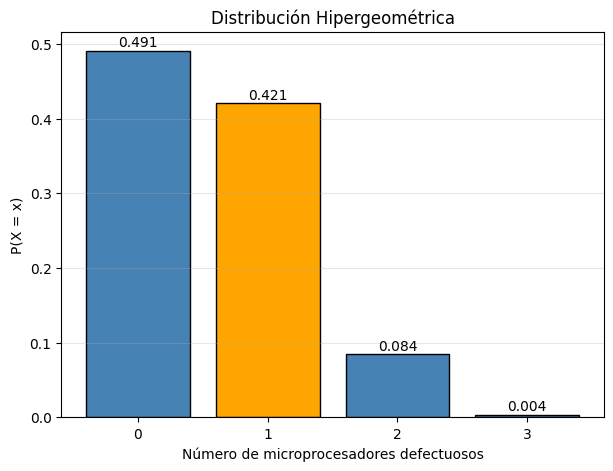

In [57]:
from scipy.stats import hypergeom

# Parámetros de la distribución
N = 20  # Tamaño del lote
K = 4   # Microprocesadores defectuosos
n = 3   # Microprocesadores seleccionados

# Valores posibles de defectuosos encontrados
x = list(range(0, min(K, n) + 1))

# Función de masa de probabilidad
probs = hypergeom.pmf(x, N, K, n)

# Probabilidad de encontrar exactamente 1 defectuoso
prob_1 = hypergeom.pmf(1, N, K, n)

# Mostrar resultado
print("Selección de microprocesadores")
print(f"Probabilidad de encontrar exactamente 1 defectuoso: {prob_1:.5f}")

# Colores: resaltar el caso x = 1
colores = ["steelblue" if k != 1 else "orange" for k in x]

# Gráfica
plt.figure(figsize=(7,5))
plt.bar(x, probs, color=colores, edgecolor='black')

plt.title("Distribución Hipergeométrica")
plt.xlabel("Número de microprocesadores defectuosos")
plt.ylabel("P(X = x)")
plt.xticks(x)
plt.grid(axis='y', alpha=0.3)

# Mostrar probabilidades sobre cada barra
for i, prob in enumerate(probs):
    plt.text(x[i], prob + 0.005, f"{prob:.3f}", ha='center', fontsize=10)

plt.show()

La selección de 3 microprocesadores de un lote de 20, donde 4 son defectuosos, puede modelarse mediante una distribución hipergeométrica.

Este modelo es apropiado porque las selecciones se realizan sin reemplazo, haciendo que la probabilidad de obtener un microprocesador defectuoso cambie después de cada extracción. Además, el cálculo de $P(X=1)$ permite determinar la probabilidad de encontrar exactamente un microprocesador defectuoso en la muestra, ilustrando cómo esta distribución es útil para problemas de control de calidad, inspección de productos y muestreo en poblaciones finitas.



---


#**Variables Aleatorias Continuas**

Una variable aleatoria continua toma valores en intervalos continuos de la recta real. Para estas variables, la probabilidad de observar un valor numérico exacto es cero ($P(X = x) = 0$).

Por ello, empleamos Funciones de Densidad de Probabilidad (f.d.p.) $f(x)$, donde las probabilidades se evalúan en intervalos mediante integración:$$P(a \le X \le b) = \int_a^b f(x) \, dx$$

## **Uniforme Continua:**

La probabilidad de que la variable caiga en un subintervalo depende únicamente de la longitud geométrica del intervalo. Su densidad es constante

**Función de densidad:**$$f(x) = \begin{cases} \frac{1}{b-a} & \text{si } a \le x \le b \\ 0 & \text{en otro caso} \end{cases}$$

**Función de distribución:**$$F(x) = \begin{cases} 0 & \text{si } x < a \\ \frac{x-a}{b-a} & \text{si } a \le x \le b \\ 1 & \text{si } x > b \end{cases}$$
**Esperanza:**$$\mathbb{E}[X] = \frac{a + b}{2}$$
**Varianza:**$$\text{Var}(X) = \frac{(b - a)^2}{12}$$

**Ejercicio:** El tiempo de espera del transporte público se distribuye de manera uniforme continua entre 2 y 10 minutos.Calcula la probabilidad de que un usuario espere entre 3 y 7 minutos. Calcula la esperanza y la varianza del tiempo de espera.

**Solución:**

$a = 2, b = 10 \implies b - a = 8$.

$P(3 \le X \le 7) = \int_{3}^{7} \frac{1}{8} \, dx = \frac{7 - 3}{8} = \frac{4}{8} = 0.50$ (50%).

$\mathbb{E}[X] = \frac{2 + 10}{2} = 6 \text{ minutos}$.

$\text{Var}(X) = \frac{(10 - 2)^2}{12} = \frac{64}{12} = \frac{16}{3} \approx 5.3333 \text{ min}^2$.

P(3 <= X <= 7) -> Teórica: 0.5000 | Simulada: 0.5016
Esperanza       -> Teórica: 6.0000 | Simulada: 5.9864
Varianza        -> Teórica: 5.3333 | Simulada: 5.3313


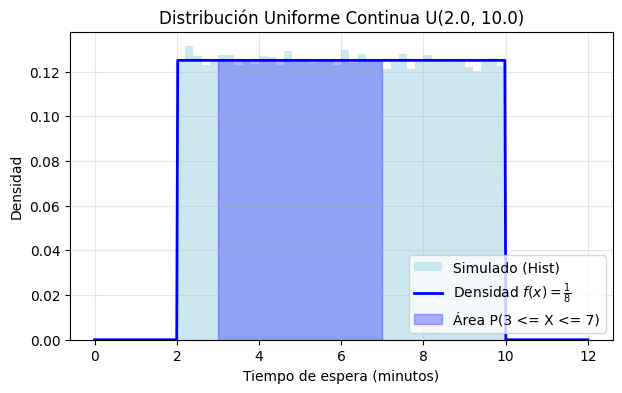

In [58]:
import numpy as np
import matplotlib.pyplot as plt

a, b = 2.0, 10.0
n_sim = 100000

# Simulación Monte Carlo
muestras_unif = np.random.uniform(a, b, n_sim)

# Probabilidad analítica vs simulada P(3 <= X <= 7)
p_teorica = (7 - 3) / (b - a)
p_simulada = np.mean((muestras_unif >= 3) & (muestras_unif <= 7))

print(f"P(3 <= X <= 7) -> Teórica: {p_teorica:.4f} | Simulada: {p_simulada:.4f}")
print(f"Esperanza       -> Teórica: {(a+b)/2:.4f} | Simulada: {np.mean(muestras_unif):.4f}")
print(f"Varianza        -> Teórica: {((b-a)**2)/12:.4f} | Simulada: {np.var(muestras_unif):.4f}")

# Visualización
x = np.linspace(0, 12, 500)
f_x = np.where((x >= a) & (x <= b), 1 / (b - a), 0)

plt.figure(figsize=(7, 4))
plt.hist(muestras_unif, bins=40, density=True, color='lightblue', alpha=0.6, label='Simulado (Hist)')
plt.plot(x, f_x, color='blue', linewidth=2, label=r'Densidad $f(x) = \frac{1}{8}$')
plt.fill_between(x, f_x, where=(x>=3)&(x<=7), color='blue', alpha=0.3, label='Área P(3 <= X <= 7)')
plt.title(f'Distribución Uniforme Continua U({a}, {b})')
plt.xlabel('Tiempo de espera (minutos)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Se contrasta la función de densidad teórica $f(x) = 1/8$ con el histograma normalizado de $100,000$ realizaciones simuladas. Asimismo, se comparan las métricas teóricas ($\mathbb{E}[X] = 6$, $\text{Var}(X) = 5.3333$, $P(3 \le X \le 7) = 0.5$) frente a los valores frecuentistas obtenidos en la muestra.

 La simulación valida el modelo teórico, la probabilidad relativa acumulada en el intervalo $[3, 7]$ estimada por simulación aproxima al $0.50$ con un margen de error menor al $0.1\%$. Gráficamente, el perfil plano del histograma confirma que en el dominio continuo $[2, 10]$ todos los subintervalos de igual longitud poseen la misma masa de probabilidad.

### **Normal o Gaussiana:**

 Descubierta en 1733 por Abraham DeMoivre para aproximar lanzamientos de monedas. Su gloria llegó en 1809 cuando Karl Friedrich Gauss la usó asombrosamente para predecir trayectorias astronómicas, y Laplace justificó que los errores de medición en la naturaleza adoptan esta forma.

Su gráfica es la famosa "campana". Depende del centro μ (esperanza) y la apertura $σ^2$(varianza). Por su simetría, rige la regla empírica: casi el 99.7% de los datos naturales caen a una distancia máxima de 3 desviaciones estándar de su media.

Es la distribución continua más importante de la probabilidad.
Modela fenómenos naturales, biológicos y sociales caracterizados por pequeñas variaciones aleatorias simétricas alrededor de un valor central.

**Función de densidad:**
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right), \quad x \in \mathbb{R}$$

**Función de distribución acumulada:**

$$F(x) = \Phi\left(\frac{x-\mu}{\sigma}\right) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\frac{x-\mu}{\sigma}} e^{-\frac{t^2}{2}} \, dt$$

**Esperanza:** $$\mathbb{E}[X] = \mu$$
**Varianza:**$$\text{Var}(X) = \sigma^2$$

**Ejercicio:** El peso de un componente fabricado en una línea automatizada sigue una distribución Normal con media $\mu = 50 \text{ g}$ y desviación estándar $\sigma = 2 \text{ g}$.Calcula la probabilidad de que un componente pese más de $53 \text{ g}$.Encuentra la varianza de la masa del componente.

**Solución:** Estandarizando a $Z \sim \mathcal{N}(0,1)$:

$Z = \frac{53 - 50}{2} = 1.5$.$P(X > 53) = P(Z > 1.5) = 1 - \Phi(1.5) \approx 1 - 0.9332 = 0.0668$ ($6.68\%$).

$\text{Var}(X) = \sigma^2 = 2^2 = 4 \text{ g}^2$.

Peso de un componente
P(X > 53) teórica:  0.0668
P(X > 53) simulada: 0.0673
Varianza: 4.00 g²


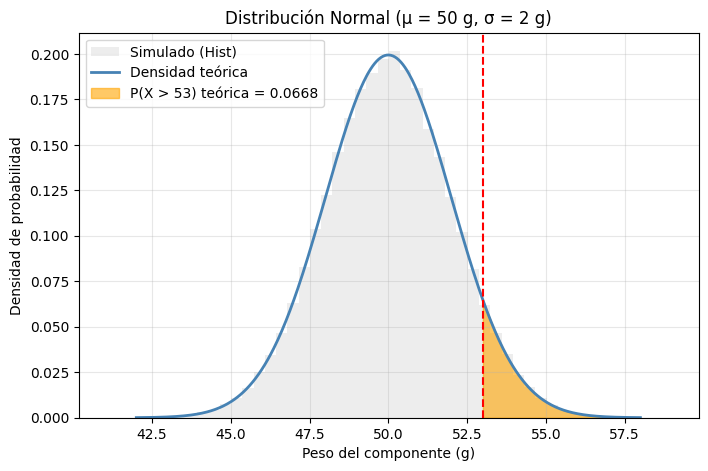

In [59]:
from scipy.stats import norm

# Parámetros de la distribución
mu = 50
sigma = 2
x = 53

# Probabilidad teórica
prob_mayor_53 = norm.sf(x, mu, sigma)
varianza = sigma ** 2

np.random.seed(42)
n_sim = 100000
muestras_normal = np.random.normal(mu, sigma, n_sim)
prob_simulada = np.mean(muestras_normal > 53)


print("Peso de un componente")
print(f"P(X > 53) teórica:  {prob_mayor_53:.4f}")
print(f"P(X > 53) simulada: {prob_simulada:.4f}")
print(f"Varianza: {varianza:.2f} g²")

# Gráfica
x_vals = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
y_vals = norm.pdf(x_vals, mu, sigma)

plt.figure(figsize=(8,5))
plt.hist(muestras_normal, bins=50, density=True, alpha=0.4,
         color='lightgray', label='Simulado (Hist)')
plt.plot(x_vals, y_vals, color='steelblue', linewidth=2, label='Densidad teórica')

x_fill = np.linspace(53, mu + 4*sigma, 200)
y_fill = norm.pdf(x_fill, mu, sigma)
plt.fill_between(x_fill, y_fill, color='orange', alpha=0.6,
                 label=f'P(X > 53) teórica = {prob_mayor_53:.4f}')
plt.axvline(53, color='red', linestyle='--')

plt.title("Distribución Normal (μ = 50 g, σ = 2 g)")
plt.xlabel("Peso del componente (g)")
plt.ylabel("Densidad de probabilidad")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Se comparó el área analítica bajo la campana de Gauss dada por $1 - \Phi(1.5)$ frente a la proporción de observaciones generadas pseudoaleatoriamente que superaron la cota de $53 \text{ g}$.

Se verifica la simetría perfecta de la distribución alrededor de $\mu = 50$. El valor simétrico simulado concuerda con la teoría analítica ($0.0668$), evidenciando que los eventos ubicados a más de $1.5$ desviaciones estándar hacia la cola derecha representan una porción minoritaria de la población total.

###**Distribución Exponencial**

Modela el tiempo continuo que transcurre entre eventos independientes que suceden a una tasa promedio constante $\lambda > 0$ (proceso de Poisson).Función de densidad $f(x)$:$$f(x) = \begin{cases} \lambda e^{-\lambda x} & \text{si } x \ge 0 \\ 0 & \text{si } x < 0 \end{cases}$$Función de distribución acumulada $F(x)$:$$F(x) = \begin{cases} 1 - e^{-\lambda x} & \text{si } x \ge 0 \\ 0 & \text{si } x < 0 \end{cases}$$Esperanza:$$\mathbb{E}[X] = \frac{1}{\lambda}$$Varianza:$$\text{Var}(X) = \frac{1}{\lambda^2}$$

**Ejercicio:** Las fallas en una maquinaria ocurren a una tasa promedio de $\lambda = 0.5 \text{ fallas/hora}$.Calcula la probabilidad de que la máquina funcione sin fallar durante al menos 3 horas. Determina el tiempo esperado hasta la siguiente falla.

**Solución:** $P(X \ge 3) = 1 - F(3) = e^{-0.5 \times 3} = e^{-1.5} \approx 0.2231$ ($22.31\%$).$\mathbb{E}[X] = \frac{1}{0.5} = 2 \text{ horas}$.

$\text{Var}(X) = \frac{1}{0.5^2} = 4 \text{ horas}^2$.

Fallas de una maquinaria
Probabilidad de funcionar al menos 3 horas: 0.2231
Tiempo esperado hasta la siguiente falla: 2.00 horas
Varianza del tiempo hasta la falla: 4.00 horas²


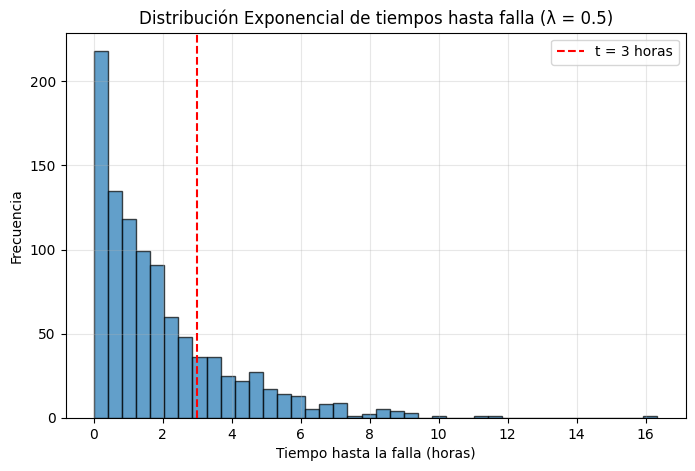

In [60]:
from scipy.stats import expon

# Parámetro de la distribución
lam = 0.5  # Tasa de fallas (fallas por hora)

# Tiempo de interés
t = 3  # horas

# Probabilidad de funcionar al menos 3 horas
# P(X >= t) = e^(-lambda*t)
prob_3_horas = expon.sf(t, scale=1/lam)

# Esperanza matemática
esperanza = 1 / lam

# Varianza
varianza = 1 / (lam ** 2)

# Mostrar resultados
print("Fallas de una maquinaria")
print(f"Probabilidad de funcionar al menos 3 horas: {prob_3_horas:.4f}")
print(f"Tiempo esperado hasta la siguiente falla: {esperanza:.2f} horas")
print(f"Varianza del tiempo hasta la falla: {varianza:.2f} horas²")

np.random.seed(42)

# Generar 1000 tiempos de falla simulados
fallas = np.random.exponential(scale=1/lam, size=1000)

# Histograma de la simulación
plt.figure(figsize=(8,5))
plt.hist(fallas, bins=40, edgecolor='black', alpha=0.7)

# Línea del tiempo de interés
plt.axvline(t, color='red', linestyle='--',
            label=f't = {t} horas')

plt.title("Distribución Exponencial de tiempos hasta falla (λ = 0.5)")
plt.xlabel("Tiempo hasta la falla (horas)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

La cercanía entre la probabilidad teórica ($≈0.2231$) y la estimación obtenida mediante la simulación confirma que el modelo exponencial representa adecuadamente el tiempo entre fallas cuando estas ocurren con una tasa constante.
La forma asimétrica positiva observada en el histograma indica que la mayoría de los tiempos de espera son cortos, concentrándose cerca de cero, mientras que existe una cola derecha que representa fallas que pueden ocurrir después de periodos más prolongados. Esta cola decrece exponencialmente conforme aumenta el tiempo de operación, reflejando una menor probabilidad de supervivencia a intervalos largos.

### **Distribución Gamma**

En un proceso de Poisson (donde los eventos ocurren aleatoriamente), la variable Exponencial modela el tiempo continuo que transcurre hasta que ocurre el siguiente evento.

Posee la asombrosa propiedad de no tener memoria (un foco viejo tiene la misma probabilidad de fundirse en el próximo minuto que uno nuevo).

La distribución Gamma generaliza a la exponencial modelando el tiempo de espera, pero hasta observar un número predeterminado α de eventos
 Generaliza la distribución Exponencial. Modela el tiempo continuo transcurrido hasta observar un número determinado $\alpha$ de eventos independientes en un proceso de Poisson con tasa $\beta$.

 **Función de densidad:** $$f(x) = \begin{cases} \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha - 1} e^{-\beta x} & \text{si } x > 0 \\ 0 & \text{si } x \le 0 \end{cases}$$donde $\Gamma(\alpha) = \int_0^\infty t^{\alpha - 1} e^{-t} \, dt$ es la función Gamma.

 **Función de distribución acumulada**:$$F(x) = \frac{\gamma(\alpha, \beta x)}{\Gamma(\alpha)}$$

 **Esperanza:**$$\mathbb{E}[X] = \frac{\alpha}{\beta}$$

 **Varianza:**$$\text{Var}(X) = \frac{\alpha}{\beta^2}$$

**Ejercicio:** En un centro de llamadas, la llegada de llamadas sigue un proceso de Poisson con tasa $\beta = 2 \text{ llamadas/minuto}$.

Se desea medir el tiempo $X$ que transcurre hasta recibir la tercera llamada ($\alpha = 3$).Calcula el tiempo promedio de espera hasta la tercera llamada.  Determina la probabilidad de esperar menos de 2 minutos para recibir las 3 llamadas.

**Solución:**
$\mathbb{E}[X] = \frac{\alpha}{\beta} = \frac{3}{2} = 1.5 \text{ minutos}$.

$\text{Var}(X) = \frac{\alpha}{\beta^2} = \frac{3}{2^2} = 0.75 \text{ min}^2$.

$P(X < 2) = F(2) = 1 - e^{-2 \times 2}\left(1 + (2 \times 2) + \frac{(2 \times 2)^2}{2!}\right) = 1 - 13 e^{-4} \approx 0.7619$ ($76.19\%$).

Tiempo hasta la tercera llamada
Tiempo esperado hasta la tercera llamada: 1.50 minutos
Varianza del tiempo de espera: 0.75 min²
Probabilidad de recibir 3 llamadas en menos de 2 minutos: 0.7619

Resultados de la simulación:
Probabilidad simulada P(X < 2): 0.7619
Media simulada: 1.5125 minutos


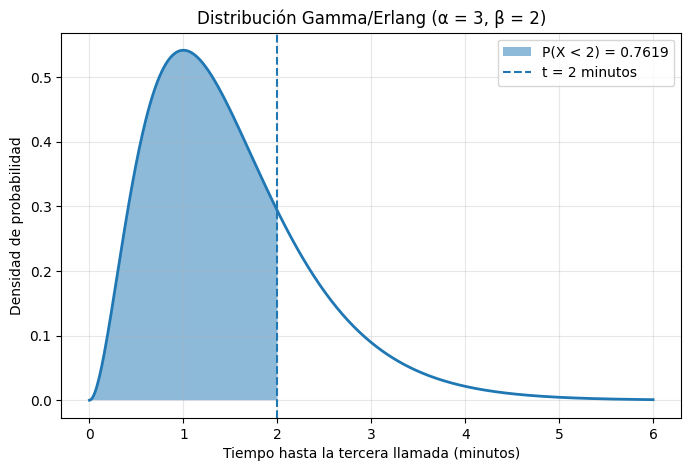

In [61]:
from scipy.stats import gamma

# Parámetros del problema
beta = 2       # Tasa de llamadas por minuto
alpha = 3      # Número de llamadas esperadas

# Parámetro de escala para scipy (scale = 1/tasa)
scale = 1 / beta

# Tiempo de interés
t = 2  # minutos

# Esperanza y varianza de la distribución Gamma/Erlang
esperanza = alpha / beta
varianza = alpha / (beta ** 2)

# Probabilidad de esperar menos de 2 minutos
prob_2_min = gamma.cdf(t, a=alpha, scale=scale)

# Mostrar resultados
print("Tiempo hasta la tercera llamada")
print(f"Tiempo esperado hasta la tercera llamada: {esperanza:.2f} minutos")
print(f"Varianza del tiempo de espera: {varianza:.2f} min²")
print(f"Probabilidad de recibir 3 llamadas en menos de 2 minutos: {prob_2_min:.4f}")


np.random.seed(42)

# Generar tiempos simulados hasta la tercera llamada
tiempos = np.random.gamma(
    shape=alpha,
    scale=scale,
    size=10000
)

# Estimación simulada de P(X < 2)
prob_simulada = np.mean(tiempos < t)

print("\nResultados de la simulación:")
print(f"Probabilidad simulada P(X < 2): {prob_simulada:.4f}")
print(f"Media simulada: {np.mean(tiempos):.4f} minutos")


x = np.linspace(0, 6, 500)
y = gamma.pdf(x, a=alpha, scale=scale)

plt.figure(figsize=(8,5))

plt.plot(x, y, linewidth=2)

# Área correspondiente a X < 2
x_fill = np.linspace(0, t, 200)
y_fill = gamma.pdf(x_fill, a=alpha, scale=scale)

plt.fill_between(
    x_fill,
    y_fill,
    alpha=0.5,
    label=f'P(X < 2) = {prob_2_min:.4f}'
)

# Línea del tiempo de interés
plt.axvline(
    t,
    linestyle='--',
    label='t = 2 minutos'
)

plt.title("Distribución Gamma/Erlang (α = 3, β = 2)")
plt.xlabel("Tiempo hasta la tercera llamada (minutos)")
plt.ylabel("Densidad de probabilidad")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

Se evaluó el valor analítico de la función acumulada $\text{Gamma}(3, 2)$ en $x = 2$ frente a la proporción empírica de simulaciones que requirieron menos de 2 minutos para acumular los 3 eventos.

A diferencia de la Exponencial (que inicia en su densidad máxima para $x=0$), la curva Gamma con $\alpha = 3$ inicia en cero y alcanza una moda sesgada antes de decaer. El resultado experimental ($\approx 0.7619$) demuestra empíricamente que la distribución Gamma actúa efectivamente como la convolución o suma de $\alpha$ variables exponenciales independientes de parámetro $\beta$.



---

### **Simulación por Transformada Inversa**
Si $U \sim \text{Uniforme}(0,1)$ y $F$ es la función de distribución acumulada de $X$,
entonces la variable $X = F^{-1}(U)$ tiene exactamente la distribución de $X$.

Esto funciona porque:
$$P(X \le x) = P(F^{-1}(U) \le x) = P(U \le F(x)) = F(x)$$

Lo aplicamos aquí a la distribución Exponencial, donde la CDF es invertible
de forma cerrada: $F(x) = 1 - e^{-\lambda x} \implies F^{-1}(u) = -\frac{1}{\lambda}\ln(1-u)$.

Transformada Inversa vs Generador directo vs Teoría
Media teórica:              2.0000
Media (transformada inv.):  1.9550
Media (generador directo):  2.0371


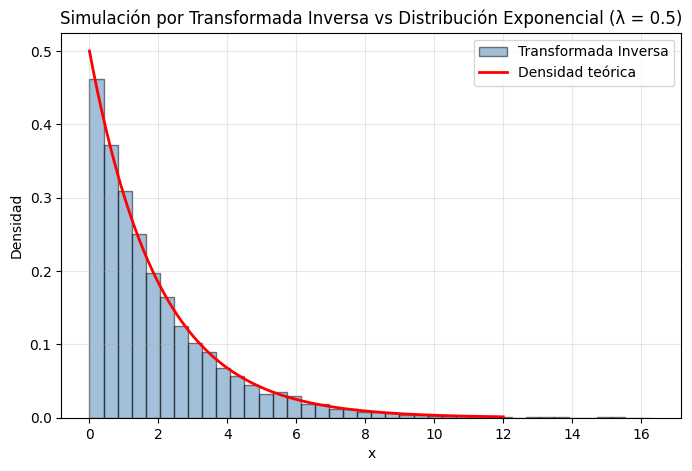

In [62]:
from scipy.stats import expon

# Parámetro de la distribución
lam = 0.5
n_sim = 10000

# Paso 1: generar números uniformes U ~ Uniforme(0,1)
np.random.seed(42)
u = np.random.uniform(0, 1, n_sim)

# Paso 2: aplicar la inversa de la CDF: F^{-1}(u) = -(1/lambda) * ln(1 - u)
x_transformada = -(1 / lam) * np.log(1 - u)

# Comparación contra la generación "directa" de scipy/numpy
x_directa = np.random.exponential(scale=1/lam, size=n_sim)

# Comparación teoría vs simulación
media_teorica = 1 / lam
print("Transformada Inversa vs Generador directo vs Teoría")
print(f"Media teórica:              {media_teorica:.4f}")
print(f"Media (transformada inv.):  {x_transformada.mean():.4f}")
print(f"Media (generador directo):  {x_directa.mean():.4f}")

# Gráfica comparativa
x_vals = np.linspace(0, 12, 400)
f_teorica = expon.pdf(x_vals, scale=1/lam)

plt.figure(figsize=(8,5))
plt.hist(x_transformada, bins=40, density=True, alpha=0.5,
         label='Transformada Inversa', color='steelblue', edgecolor='black')
plt.plot(x_vals, f_teorica, color='red', linewidth=2, label='Densidad teórica')
plt.title('Simulación por Transformada Inversa vs Distribución Exponencial (λ = 0.5)')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Las medias muestrales obtenidas por transformada inversa y por el generador
directo de NumPy coinciden con la media teórica ($1/\lambda = 2$), y el
histograma de los datos generados por transformada inversa se ajusta
correctamente a la densidad exponencial teórica. Esto confirma que aplicar
$F^{-1}$ a números uniformes reproduce fielmente la distribución deseada,
sin depender de que scipy/numpy tengan un generador nativo para esa distribución.



---


# **Funciones de Distribución, Momentos y Funciones Generadoras**

Los "momentos" de una distribución nos resumen sus características físicas: el primer momento es su centro de gravedad (la media), el segundo central es su momento de inercia o dispersión (la varianza), el tercero nos da la asimetría, etc.

###**Función Generadora de Momentos (FGM):**

Si expandimos la función $e^{tX}$ en su serie de Taylor:

$$e^{tX} = 1 + tX + \frac{(tX)^2}{2!} + \frac{(tX)^3}{3!} + \dots$$vemos que contiene adentro todas las potencias de $X$.

Al tomar la esperanza matemática, la Función Generadora de Momentos (FGM) adopta la forma:$$M_X(t) = \mathbb{E}[e^{tX}] = 1 + t\mathbb{E}[X] + \frac{t^2}{2!}\mathbb{E}[X^2] + \frac{t^3}{3!}\mathbb{E}[X^3] + \dots$$Al derivar la FGM $k$ veces respecto a $t$ y evaluarla en $t = 0$, los demás términos se eliminan y la función nos entrega directamente el momento deseado:$$\mathbb{E}[X^k] = \left. \frac{d^k M_X(t)}{dt^k} \right\vert{}_{t=0}$$Además, por el Teorema de Unicidad, si dos variables aleatorias comparten la misma FGM en un entorno de $t = 0$, obligatoriamente tienen la misma distribución de probabilidad.


Sea $X$ una variable aleatoria.

La Función Generadora de Momentos $M_X(t)$ se define como la esperanza de $e^{tX}$:$$M_X(t) = \mathbb{E}[e^{tX}]$$ para aquellos valores de $t \in \mathbb{R}$ en los cuales el valor esperado exista en un entorno de $t = 0$.

**Propiedades:**

Evaluación en el origen: $M_X(0) = \mathbb{E}[e^{0}] = 1$.Transformación lineal: Si $Y = aX + b$, entonces:$$M_Y(t) = e^{bt} M_X(at)$$Suma de variables independientes: Si $X_1, X_2, \dots, X_n$ son variables aleatorias independientes, la FGM de la suma $S_n = \sum_{i=1}^n X_i$ es el producto de sus FGMs individuales:$$M_{S_n}(t) = \prod_{i=1}^n M_{X_i}(t)$$

Unicidad: Si dos variables aleatorias tienen la misma FGM en un entorno de $t = 0$, entonces tienen exactamente la misma función de distribución de probabilidad.

**Obtención de momentos mediante derivación:**

Expandiendo $e^{tX}$ en serie de Maclaurin:$$M_X(t) = \mathbb{E}\left[ 1 + tX + \frac{(tX)^2}{2!} + \frac{(tX)^3}{3!} + \dots \right] = 1 + t\mathbb{E}[X] + \frac{t^2}{2!}\mathbb{E}[X^2] + \frac{t^3}{3!}\mathbb{E}[X^3] + \dots$$Derivando sucesivamente respecto a $t$ y evaluando en $t = 0$:

**Primer momento (Media / Esperanza):** $$\mathbb{E}[X] = M_X'(0) = \left. \frac{d M_X(t)}{dt} \right\vert{}_{t=0}$$

**Segundo momento ordinario:** $$\mathbb{E}[X^2] = M_X''(0) = \left. \frac{d^2 M_X(t)}{dt^2} \right\vert{}_{t=0}$$

**Varianza:**$$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = M_X''(0) - [M_X'(0)]^2$$

**Ejemplo:** Obtén la FGM de $X \sim \text{Bernoulli}(p)$ y calcula $\mathbb{E}[X]$ y $\text{Var}(X)$ derivando.

**Solución:** $$M_X(t) = e^{t(0)}(1-p) + e^{t(1)}p = (1-p) + p e^t$$$M_X'(t) = p e^t \implies M_X'(0) = p \cdot e^0 = p = \mathbb{E}[X]$.$M_X''(t) = p e^t \implies M_X''(0) = p \cdot e^0 = p = \mathbb{E}[X^2]$.

$\text{Var}(X) = M_X''(0) - [M_X'(0)]^2 = p - p^2 = p(1-p)$.

FGM de Bernoulli:
M_X(t) = 0.7*exp(t) + 0.3

Derivadas:
M_X'(t) = 0.7*exp(t)
M_X''(t) = 0.7*exp(t)

Momentos:
E[X] = 0.700000000000000
E[X²] = 0.700000000000000

Varianza:
Var(X) = 0.210000000000000


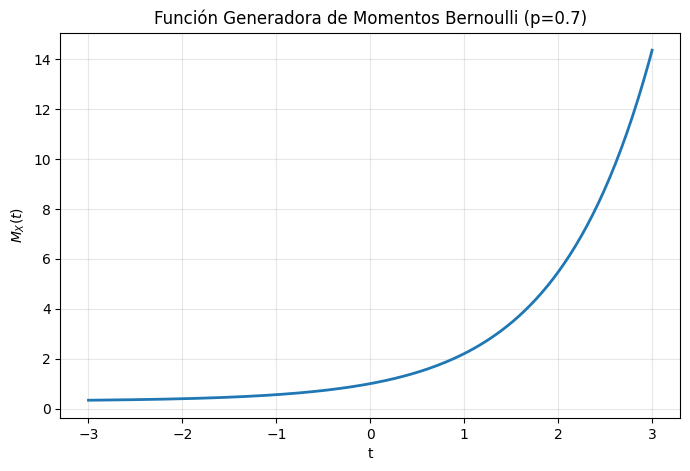

In [63]:
import sympy as sp
# Parámetro de Bernoulli
p = 0.7

# Variable simbólica
t = sp.symbols('t')

Mx = (1 - p) + p * sp.exp(t)

print("FGM de Bernoulli:")
print("M_X(t) =", Mx)


# Primera derivada
Mx_primera = sp.diff(Mx, t)

# Segunda derivada
Mx_segunda = sp.diff(Mx, t, 2)


# Evaluación en t = 0
esperanza = Mx_primera.subs(t, 0)
momento_segundo = Mx_segunda.subs(t, 0)

# Varianza
varianza = momento_segundo - esperanza**2


print("\nDerivadas:")
print("M_X'(t) =", Mx_primera)
print("M_X''(t) =", Mx_segunda)

print("\nMomentos:")
print("E[X] =", esperanza)
print("E[X²] =", momento_segundo)

print("\nVarianza:")
print("Var(X) =", sp.simplify(varianza))


t_values = np.linspace(-3, 3, 200)

Mx_values = [
    (1-p) + p*np.exp(valor)
    for valor in t_values
]


plt.figure(figsize=(8,5))

plt.plot(t_values, Mx_values, linewidth=2)

plt.title(f"Función Generadora de Momentos Bernoulli (p={p})")
plt.xlabel("t")
plt.ylabel("$M_X(t)$")
plt.grid(alpha=0.3)

plt.show()

Interpretación de la Esperanza:

$$\mathbb{E}[X] = p = 0.7$$Para una variable aleatoria Bernoulli, la esperanza coincide exactamente con la probabilidad del evento "Éxito" ($1$).

Varianza:$$\text{Var}(X) = p(1 - p) = 0.7(1 - 0.7) = 0.7 \times 0.3 = 0.21$$Muestra de forma impecable la dispersión del experimento alrededor de su media.

La primera derivada evaluada en la vecindad del origen $t=0$ devuelve el primer momento (la esperanza):$$M_X'(0) = \mathbb{E}[X] = p$$

La segunda derivada evaluada en $t=0$ devuelve el segundo momento ordinario:$$M_X''(0) = \mathbb{E}[X^2] = p$$

La varianza se recupera mediante la relación fundamental:$$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = M_X''(0) - [M_X'(0)]^2 = 0.7 - (0.7)^2 = 0.7 - 0.49 = 0.21$$

###**Función Característica (FC):**
Utiliza la unidad imaginaria $i = \sqrt{-1}$. La FGM tradicional a veces no existe (la integral o suma diverge a infinito) para distribuciones con colas pesadas. En cambio, la Función Característica siempre existe y está acotada ($\vert{}\varphi_X(t)\vert{} \le 1$) para absolutamente cualquier distribución de probabilidad, caracterizándola de manera única e inequívoca.


Sea $X$ una variable aleatoria.

La Función Característica $\varphi_X(t)$ se define como el valor esperado de $e^{itX}$, donde $i = \sqrt{-1}$:$$\varphi_X(t) = \mathbb{E}[e^{itX}] = \mathbb{E}[\cos(tX)] + i \mathbb{E}[\sin(tX)]$$

**Propiedades:**

Existencia universal: A diferencia de la FGM, la FC siempre existe para absolutamente cualquier variable aleatoria, ya que $\vert{}e^{itX}\vert{} = 1$.

Acotamiento: $\vert{}\varphi_X(t)\vert{} \le \varphi_X(0) = 1$ para todo $t \in \mathbb{R}$.

Conjugación simétrica: $\varphi_X(-t) = \overline{\varphi_X(t)}$ (donde la barra denota el conjugado complejo).

Caracterización única: La Función Característica determina de manera única e inequívoca la distribución de probabilidad de $X$ (Teorema de Inversión).

Relación con los momentos: Si el $k$-ésimo momento $\mathbb{E}[X^k]$ existe, se puede obtener derivando la FC $k$ veces respecto a $t$ y dividiendo entre $i^k$:$$\mathbb{E}[X^k] = \frac{1}{i^k} \left. \frac{d^k \varphi_X(t)}{dt^k} \right\vert{}_{t=0} = (-i)^k \varphi_X^{(k)}(0)$$

**Ejemplo:** Obtén la FC de una variable continua $X \sim \text{Uniforme}(-a, a)$.

**Solución:** $$\varphi_X(t) = \int_{-a}^{a} e^{itx} \frac{1}{2a} \, dx = \frac{1}{2a} \left[ \frac{e^{itx}}{it} \right]_{-a}^{a} = \frac{e^{ita} - e^{-ita}}{2i a t} = \frac{\sin(at)}{at}$$

Función Característica:
φ_X(t) = Piecewise((0.5*sin(2*t)/t, (t > 0) | (t < 0)), (1.0, True))

Forma simplificada:
φ_X(t) = sin(2*t)/(2*t)


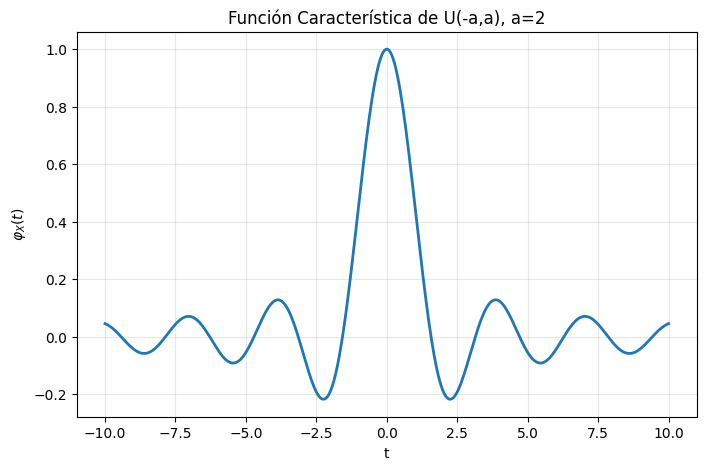

In [64]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
a = 2

# Variables simbólicas
x, t = sp.symbols('x t', real=True)

# Densidad uniforme (-a,a)
f = 1 / (2*a)

# Integral de la FC
phi = sp.integrate(
    sp.exp(sp.I*t*x) * f,
    (x, -a, a)
)

# Simplificación
phi_simplificada = sp.simplify(phi)

print("Función Característica:")
print("φ_X(t) =", phi_simplificada)


# Forma equivalente:
phi_teorica = sp.sin(a*t)/(a*t)

print("\nForma simplificada:")
print("φ_X(t) =", phi_teorica)

t_values = np.linspace(-10, 10, 400)

# Evitar división entre cero en t=0
phi_values = np.array([
    np.sin(a*valor)/(a*valor) if valor != 0 else 1
    for valor in t_values
])


plt.figure(figsize=(8,5))

plt.plot(t_values, phi_values, linewidth=2)

plt.title(f"Función Característica de U(-a,a), a={a}")
plt.xlabel("t")
plt.ylabel("$φ_X(t)$")
plt.grid(alpha=0.3)

plt.show()

La función característica para $X \sim U(-a, a)$ es:

$$\varphi_X(t) = \frac{\sin(at)}{at}$$

Para el caso particular con $a = 2$:$$\varphi_X(t) = \frac{\sin(2t)}{2t}$$

Propiedades principales:En $t = 0$: $\varphi_X(0) = 1$, ya que:$$\lim_{t \to 0} \frac{\sin(at)}{at} = 1$$

Simetría: Es puramente real y par, pues la distribución $U(-a, a)$ está centrada en cero.

Comportamiento en frecuencia: La oscilación amortiguada adopta la forma de una función tipo $\text{sinc}$, característica de un pulso rectangular en el dominio de frecuencias.

Unicidad: Existirá siempre para cualquier variable aleatoria continua y determina de forma única a la distribución original.

###**Ley de los Grandes Números (LGN)**


Cardano notó la estabilización de los datos en el siglo XVI, pero Jacobo Bernoulli la demostró rigurosamente en 1713.

Si repites un experimento infinitas veces, el promedio de los resultados convergerá inevitablemente a la esperanza matemática teórica μ.
Esto da la justificación teórica de por qué la frecuencia empírica funciona en la vida real

Sea $X_1, X_2, \dots, X_n$ una secuencia de variables aleatorias independientes e idénticamente distribuidas (i.i.d.) con esperanza finita $\mathbb{E}[X_i] = \mu$.

La Ley Débil de los Grandes Números establece que el promedio muestral $\bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i$ converge en probabilidad hacia la media teórica $\mu$:$$\lim_{n \to \infty} P(\vert{}\bar{X}_n - \mu\vert{} \ge \epsilon) = 0, \quad \forall \epsilon > 0$$

A medida que el tamaño de muestra $n$ aumenta, el promedio de las observaciones se estabiliza de forma cuantitativa y converge hacia el valor esperado teórico $\mu$.

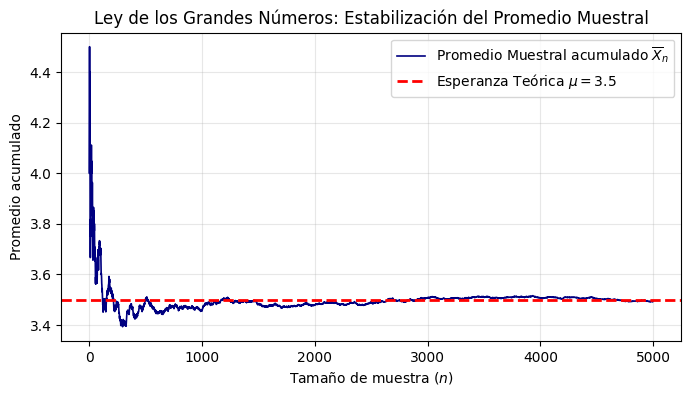

In [65]:
np.random.seed(42)
n_max = 5000

# Simulación de lanzamientos de un dado justo (E[X] = 3.5)
lanzamientos = np.random.choice([1, 2, 3, 4, 5, 6], size=n_max)
promedios_acumulados = np.cumsum(lanzamientos) / np.arange(1, n_max + 1)

plt.figure(figsize=(8, 4))
plt.plot(promedios_acumulados, color='navy', linewidth=1.2, label=r'Promedio Muestral acumulado $\overline{X}_n$')
plt.axhline(3.5, color='red', linestyle='--', linewidth=2, label=r'Esperanza Teórica $\mu = 3.5$')
plt.title('Ley de los Grandes Números: Estabilización del Promedio Muestral')
plt.xlabel('Tamaño de muestra ($n$)')
plt.ylabel('Promedio acumulado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

La evolución del promedio muestral acumulado $\bar{X}_n$ para un dado justo conforme $n$ crece desde $1$ hasta $5,000$ ensayos frente a la media teórica fija $\mu = 3.5$.

Para valores pequeños de $n$ ($n < 200$), la media muestral presenta fluctuaciones de alta amplitud. Conforme $n \to 5,000$, la oscilación se amortigua por completo y la trayectoria colapsa exactamente sobre la línea teórica en $3.5$, demostrando el fundamento de la inferencia frecuentista.

###**Teorema Central del Límite (TCL):**

Planteado por DeMoivre (1733) y expandido por Laplace (1812), hasta ser probado rigurosamente por Liapounoff (1901).

Es el teorema más mágico de la estadística. Dicta que, si sumas muchas variables aleatorias independientes, no importa si la distribución original era cuadrada, triangular o deforme: la suma de todas ellas siempre se transformará en una campana de Gauss (Distribución Normal).

Esto explica por qué en la naturaleza casi todo (altura, errores, inteligencia) se distribuye normalmente, ya que somos la suma de miles de pequeños factores genéticos y ambientales


Sea $X_1, X_2, \dots, X_n$ una secuencia de variables aleatorias i.i.d. con media $\mu$ y varianza finita $\sigma^2 > 0$.

El Teorema Central del Límite establece que la variable estandarizada $Z_n$ construida a partir de la suma o del promedio muestral converge en distribución hacia una Normal estándar $\mathcal{N}(0, 1)$ conforme $n \to \infty$:$$Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1) \quad \text{cuando } n \to \infty$$

Independientemente de la forma o asimetría de la distribución original de las $X_i$ (discreta, uniforme, exponencial, etc.), la distribución de las medias muestrales adopta la forma de una campana de Gauss simétrica al aumentar $n$.

<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2209/209731169.py:28: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Promedio Muestral ($\overline{X}_n$)')


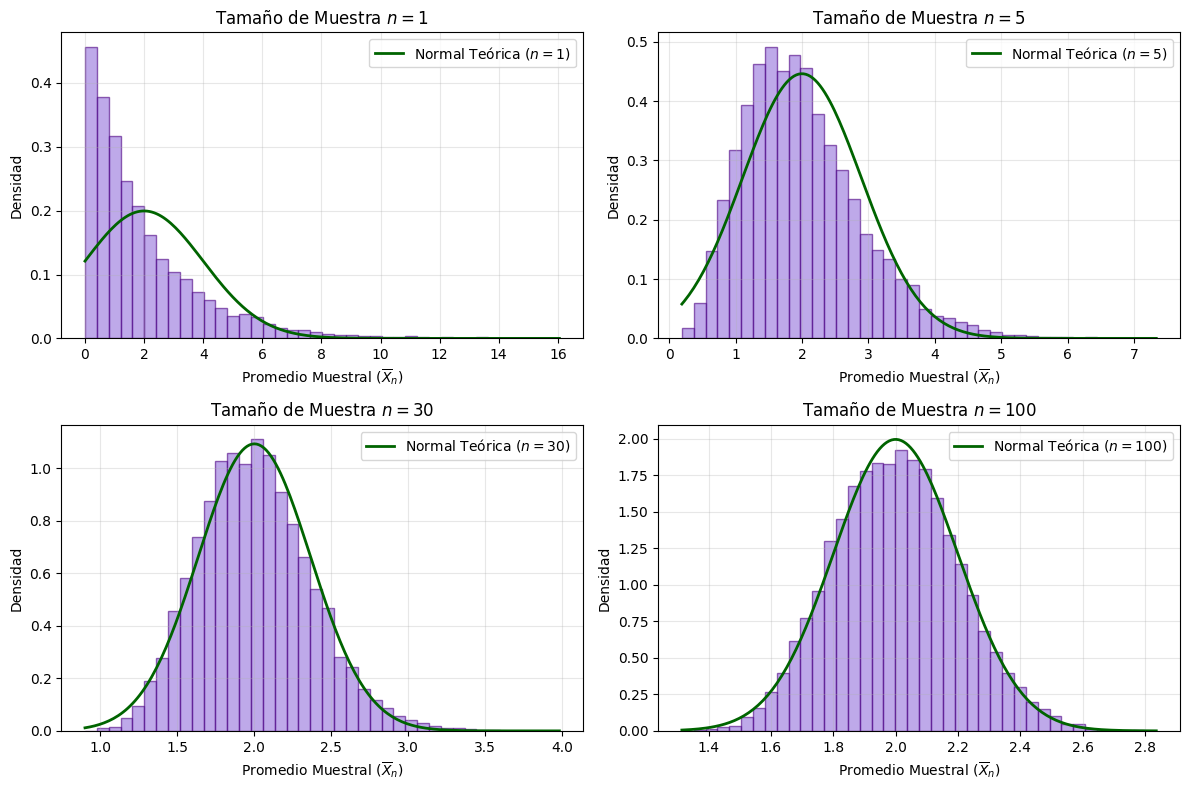

In [66]:
# Muestreamos de una distribución Exponencial(lambda=0.5), que es fuertemente asimétrica
lam = 0.5
mu_teorica = 1 / lam          # 2.0
sigma_teorica = 1 / lam       # 2.0

n_muestras_list = [1, 5, 30, 100]  # Tamaños de suma/promedio
n_experimentos = 10000

plt.figure(figsize=(12, 8))

for idx, n in enumerate(n_muestras_list, 1):
    # Generamos matriz de experimentos
    muestras = np.random.exponential(scale=1/lam, size=(n_experimentos, n))
    promedios = np.mean(muestras, axis=1)

    # Parámetros del promedio muestral
    sigma_promedio = sigma_teorica / np.sqrt(n)

    plt.subplot(2, 2, idx)
    plt.hist(promedios, bins=40, density=True, color='mediumpurple', alpha=0.6, edgecolor='indigo')

    # Curva Normal límite
    x = np.linspace(min(promedios), max(promedios), 200)
    f_normal = (1 / (sigma_promedio * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu_teorica) / sigma_promedio)**2)
    plt.plot(x, f_normal, color='darkgreen', linewidth=2, label=f'Normal Teórica ($n={n}$)')

    plt.title(f'Tamaño de Muestra $n = {n}$')
    plt.xlabel('Promedio Muestral ($\overline{X}_n$)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La distribución empírica del promedio muestral de variables exponenciales (cuya densidad original es fuertemente sesgada a la derecha para $n=1$) contra la curva límite Gaussiana $\mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$ al incrementar $n$ ($n = 1, 5, 30, 100$).

Para $n = 1$, el histograma hereda la asimetría decreciente exponencial. A medida que $n$ aumenta a $5$ y luego a $30$, la asimetría desaparece progresivamente y la distribución de los promedios se vuelve simétrica, ajustándose con precisión casi perfecta a la campana de Gauss para $n = 100$. Esto confirma que la agregación de múltiples factores estocásticos independientes genera normalidad asintótica.

# **Conclusión**

Las distribuciones de probabilidad, ya sean discretas o continuas, nos permiten construir modelos teóricos para describir el comportamiento de fenómenos aleatorios asignando probabilidades a sus posibles resultados.

Para resumir la información y las características físicas de estas distribuciones, calculamos sus momentos; por ejemplo, el primer momento nos da la esperanza matemática (el centro de gravedad o valor esperado) y el segundo momento central nos proporciona la varianza (la dispersión de los datos).

Aquí es donde revelan su valor herramientas analíticas como la Función Generadora de Momentos (FGM) y la Función Característica (FC). La FGM nos permite extraer cualquier momento de una variable aleatoria mediante sucesivas derivadas matemáticas evaluadas en cero, lo que frecuentemente evita el cálculo directo de sumas o integrales sumamente complejas.

Aún más importante, tanto la FGM como la FC poseen la propiedad de caracterizar de manera única a su distribución de probabilidad. Es decir, si dos variables comparten la misma función generadora, obligatoriamente comparten la misma distribución.

Por otro lado, la simulación nos permite llevar estos modelos teóricos puramente abstractos a la experimentación empírica.

Mediante el método de la transformada inversa, comprobamos que es posible utilizar números pseudoaleatorios y mapearlos a través de la función de distribución acumulada inversa para generar observaciones que sigan perfectamente cualquier distribución teórica continua deseada.

Finalmente, esta experimentación empírica mediante simulaciones encuentra su validación y culminación en los grandes teoremas límite:

La Ley de los Grandes Números (LGN) conecta las simulaciones con los momentos, al establecer que conforme aumentamos el tamaño de nuestra muestra aleatoria (es decir, el número de simulaciones), el promedio empírico de nuestros datos convergerá invariablemente hacia el primer momento teórico poblacional, es decir la esperanza matemática.

El Teorema Central del Límite (TCL) corona la teoría demostrando, frecuentemente con la ayuda de las propiedades de la FGM en su demostración, que la suma o el promedio de una gran cantidad de variables aleatorias independientes se aproximará siempre a una distribución Normal estándar. Esto ocurre sin importar cuán caótica o deforme fuera la distribución original de los datos simulados, lo que explica por qué la campana de Gauss es el modelo por excelencia para describir la naturaleza.

En resumen, los momentos definen la forma de la distribución, la FGM y FC encapsulan su identidad, la simulación materializa la teoría en datos, la LGN garantiza que esos datos encuentren su centro teórico, y el TCL asegura que, a nivel macroscópico, el caos siempre convergerá en la normalidad.


## **Bibliografía**

Rincón, L. (2014). Introducción a la probabilidad (1ª ed.). Ciudad de México: Facultad de Ciencias, Universidad Nacional Autónoma de México.

Rincón, L. (2019). Una introducción a la estadística inferencial (1ª ed.). Ciudad de México: Facultad de Ciencias, Universidad Nacional Autónoma de México.

Ross, S. M. (2010). A First Course in Probability (8ª ed.). Upper Saddle River, NJ: Pearson Prentice Hall.

Wackerly, D. D., Mendenhall III, W., & Scheaffer, R. L. (2010). Estadística matemática con aplicaciones (7ª ed.). México, D.F.: Cengage Learning.

Reyes Montes de Oca, C. C. (2026). Probabilidad: Variables Aleatorias Discretas y Continuas. FES Acatlán, UNAM.